Loading Datasets...
Base Time-Series Loaded. Shape: (5568, 7)
Fluid features added.


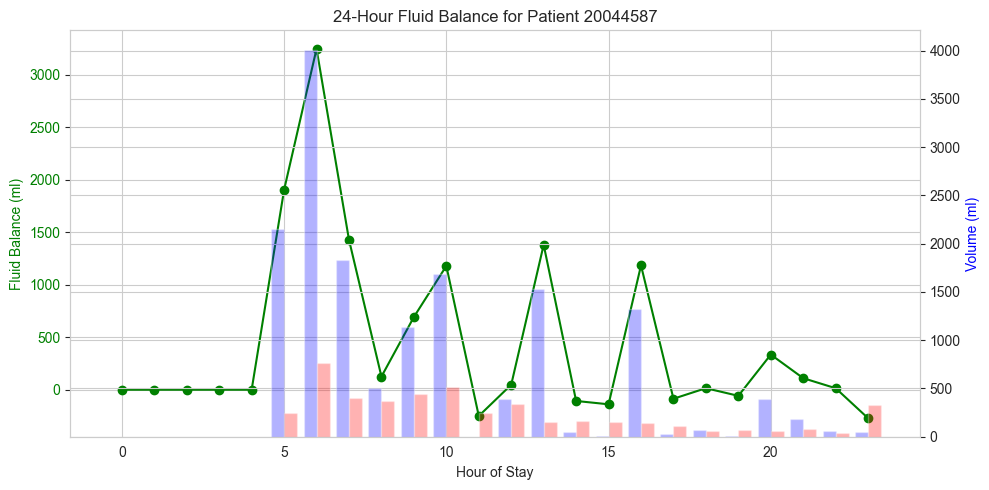

Output saved to C:\AINutriCare\Data\Transformed\processed_mimic_24h_io_combined.csv
      hadm_id  hour_bin  Creatinine     Glucose  Lactate  Potassium  \
0  20044587.0         0    1.504829  147.330645      1.4   4.131132   
1  20044587.0         1    1.504829  147.330645      2.7   4.131132   
2  20044587.0         2    1.504829  147.330645      1.8   4.131132   
3  20044587.0         3    1.504829  147.330645      1.8   4.131132   
4  20044587.0         4    1.504829  147.330645      2.7   4.131132   

       Sodium    pH  HeartRate  TotalInput  TotalOutput  FluidBalance  
0  137.384556  7.37  87.433344         0.0          0.0           0.0  
1  137.384556  7.40  87.433344         0.0          0.0           0.0  
2  137.384556  7.45  87.433344         0.0          0.0           0.0  
3  137.384556  7.45  87.433344         0.0          0.0           0.0  
4  137.384556  7.34  87.433344         0.0          0.0           0.0  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Path Configuration
raw_dir = r"C:\AINutriCare\Data\Raw"
processed_dir = r"C:\AINutriCare\Data\Transformed"

def get_raw_path(filename):
    return os.path.join(raw_dir, filename)

def get_processed_path(filename):
    return os.path.join(processed_dir, filename)

try:
    print("Loading Datasets...")
    admissions = pd.read_csv(get_raw_path('admissions.csv'), parse_dates=['admittime'])
    inputevents = pd.read_csv(get_raw_path('inputevents.csv'), parse_dates=['starttime'])
    outputevents = pd.read_csv(get_raw_path('outputevents.csv'), parse_dates=['charttime'])
    
    # Load from Transformed folder
    base_df = pd.read_csv(get_processed_path('processed_mimic_24h_combined.csv'))
    
    if 'hadm_id' in base_df.columns and 'hour_bin' in base_df.columns:
        base_df.set_index(['hadm_id', 'hour_bin'], inplace=True)
    
    print(f"Base Time-Series Loaded. Shape: {base_df.shape}")

    if not base_df.empty:
        # --- Process InputEvents (IV Fluids) ---
        inputs_merged = pd.merge(inputevents, admissions[['hadm_id', 'admittime']], on='hadm_id', how='inner')
        inputs_merged['hours_in'] = (inputs_merged['starttime'] - inputs_merged['admittime']).dt.total_seconds() / 3600
        
        inputs_24h = inputs_merged[(inputs_merged['hours_in'] >= 0) & (inputs_merged['hours_in'] <= 24)].copy()
        inputs_24h['hour_bin'] = np.floor(inputs_24h['hours_in']).astype(int)
        
        inputs_pivot = inputs_24h.pivot_table(index=['hadm_id', 'hour_bin'], values='amount', aggfunc='sum').rename(columns={'amount': 'TotalInput'})

        # --- Process OutputEvents (Urine/Fluid Out) ---
        outputs_merged = pd.merge(outputevents, admissions[['hadm_id', 'admittime']], on='hadm_id', how='inner')
        outputs_merged['hours_in'] = (outputs_merged['charttime'] - outputs_merged['admittime']).dt.total_seconds() / 3600
        
        outputs_24h = outputs_merged[(outputs_merged['hours_in'] >= 0) & (outputs_merged['hours_in'] <= 24)].copy()
        outputs_24h['hour_bin'] = np.floor(outputs_24h['hours_in']).astype(int)
        
        outputs_pivot = outputs_24h.pivot_table(index=['hadm_id', 'hour_bin'], values='value', aggfunc='sum').rename(columns={'value': 'TotalOutput'})

        # --- Merge & Compute Balance ---
        full_df = base_df.join(inputs_pivot).join(outputs_pivot)
        full_df['TotalInput'] = full_df['TotalInput'].fillna(0)
        full_df['TotalOutput'] = full_df['TotalOutput'].fillna(0)
        full_df['FluidBalance'] = full_df['TotalInput'] - full_df['TotalOutput']
        
        print("Fluid features added.")

        # --- Visualization ---
        try:
            sample_stay = inputs_pivot.index.get_level_values(0)[0]
            sample_data = full_df.loc[sample_stay]

            fig, ax1 = plt.subplots(figsize=(10, 5))
            ax1.plot(sample_data.index, sample_data['FluidBalance'], 'g-o', label='Fluid Balance')
            ax1.set_xlabel('Hour of Stay')
            ax1.set_ylabel('Fluid Balance (ml)', color='g')
            ax1.tick_params(axis='y', labelcolor='g')
            ax1.set_title(f'24-Hour Fluid Balance for Patient {sample_stay}')
            
            ax2 = ax1.twinx()
            ax2.bar(sample_data.index - 0.2, sample_data['TotalInput'], width=0.4, alpha=0.3, color='b', label='Input')
            ax2.bar(sample_data.index + 0.2, sample_data['TotalOutput'], width=0.4, alpha=0.3, color='r', label='Output')
            ax2.set_ylabel('Volume (ml)', color='b')
            
            fig.tight_layout()
            plt.show()
        except (IndexError, KeyError):
            print("No matching stay found for visualization.")

        # --- Save Output to Transformed ---
        output_filename = get_processed_path('processed_mimic_24h_io_combined.csv')
        full_df.reset_index(inplace=True)
        full_df.to_csv(output_filename, index=False)
        print(f"Output saved to {output_filename}")
        print(full_df.head())

except FileNotFoundError as e:
    print(f"Error: File not found. Please check paths. Details: {e}")